In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/product_return_prediction.csv")

df.head()

,order_id,product_id,price,rating,return_status
0,O0001,P909,141.90,3,0
1,O0002,P778,232.72,3,0
2,O0003,P508,496.90,3,0
3,O0004,P763,138.81,3,0
4,O0005,P255,453.40,1,1


In [3]:
df.shape


(1500, 5)

In [4]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       1500 non-null   object 
 1   product_id     1500 non-null   object 
 2   price          1500 non-null   float64
 3   rating         1500 non-null   int64  
 4   return_status  1500 non-null   int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 58.7+ KB


In [6]:
df.describe()

,price,rating,return_status
count,1500.000000,1500.000000,1500.000000
mean,251.344100,2.985333,0.270667
std,139.258771,1.404196,0.444452
min,10.430000,1.000000,0.000000
25%,131.625000,2.000000,0.000000
50%,250.135000,3.000000,0.000000
75%,367.025000,4.000000,1.000000
max,499.690000,5.000000,1.000000


In [7]:
df.isnull().sum()

order_id         0
product_id       0
price            0
rating           0
return_status    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
print(df['return_status'].value_counts())

print(df['rating'].value_counts())

print(df['price'].describe())

return_status
0    1094
1     406
Name: count, dtype: int64
rating
3    311
2    302
1    299
4    298
5    290
Name: count, dtype: int64
count    1500.000000
mean      251.344100
std       139.258771
min        10.430000
25%       131.625000
50%       250.135000
75%       367.025000
max       499.690000
Name: price, dtype: float64


72.9% orders are not returned.
27.1% orders are returned.
Dataset is mildly imbalanced but not severely imbalanced.

Very balanced ratings.

No rating value dominates the dataset.

This is good because the model won't be biased toward a particular rating level.

Price appears fairly evenly distributed.
Mean and median are very close.
No obvious skewness.

# EDA

Return Status

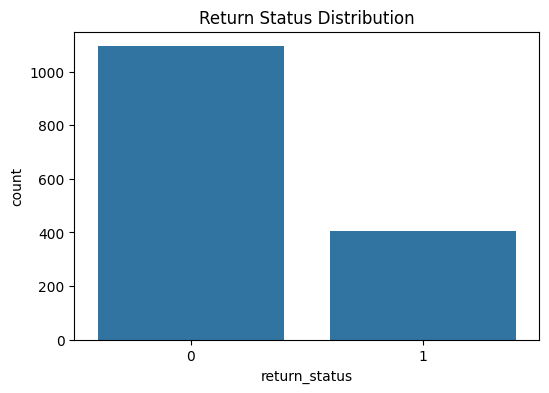

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='return_status', data=df)
plt.title("Return Status Distribution")
plt.show()

Rating

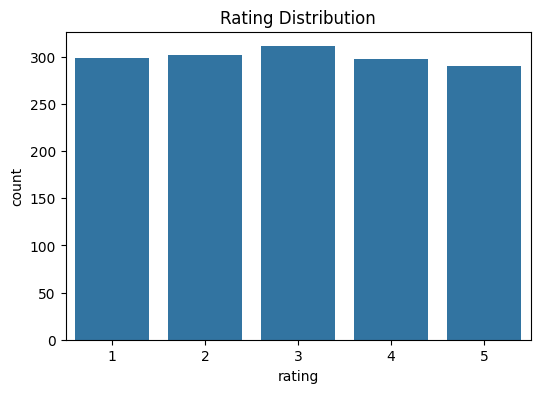

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='rating', data=df)
plt.title("Rating Distribution")
plt.show()

Price Histogram

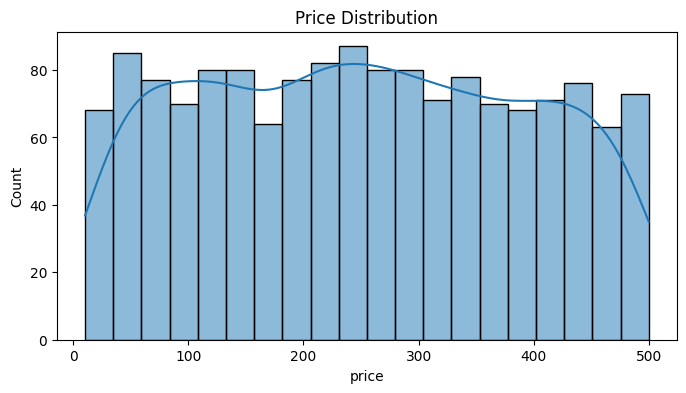

In [12]:
plt.figure(figsize=(8,4))
sns.histplot(df['price'], bins=20, kde=True)
plt.title("Price Distribution")
plt.show()

Price vs Return Status

 will tell us if expensive products are returned more often.

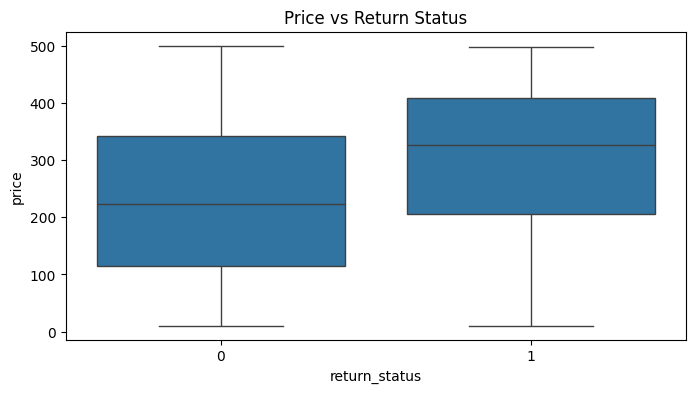

In [13]:
plt.figure(figsize=(8,4))
sns.boxplot(x='return_status', y='price', data=df)
plt.title("Price vs Return Status")
plt.show()

Rating vs Return Status

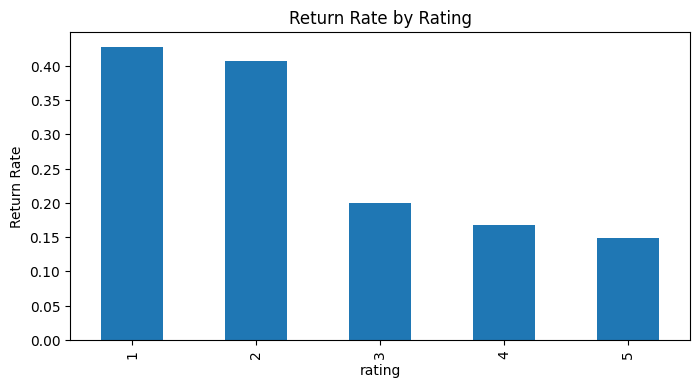

In [14]:
return_by_rating = pd.crosstab(
    df['rating'],
    df['return_status'],
    normalize='index'
)

return_by_rating[1].plot(
    kind='bar',
    figsize=(8,4)
)

plt.ylabel("Return Rate")
plt.title("Return Rate by Rating")
plt.show()

Correlation Heatmap

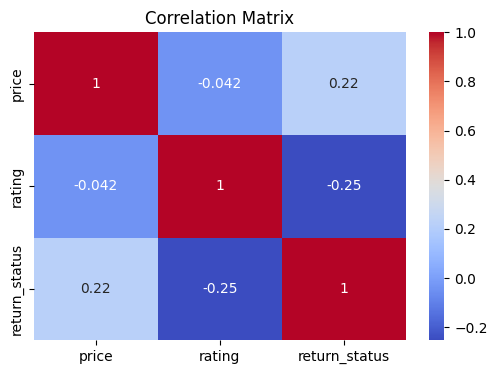

In [15]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df[['price','rating','return_status']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [16]:
df.groupby('rating')['return_status'].mean()

rating
1    0.428094
2    0.407285
3    0.199357
4    0.167785
5    0.148276
Name: return_status, dtype: float64

In [17]:
df.groupby('product_id')['return_status'].mean().sort_values(ascending=False).head(10)

product_id
P336    1.0
P482    1.0
P297    1.0
P206    1.0
P360    1.0
P444    1.0
P450    1.0
P201    1.0
P452    1.0
P199    1.0
Name: return_status, dtype: float64

In [18]:
df['product_id'].value_counts().loc[
    ['P336','P482','P297','P206','P360']
]

product_id
P336    1
P482    1
P297    3
P206    1
P360    1
Name: count, dtype: int64